## Математические методы биоинформатики

### Home work 2. Проверка статистических гипотез

### Задание.

В файле *immunology_dataset.csv* представлены иммунологические данные для трех групп людей (переменная Group):

- Здоровые (Healthy)  
- Пациенты с аутоиммунным заболеванием (Autoimmune)  
- Пациенты с  онкологическим заболеванием (Cancer)  

Для каждого пациента измерены следующие показатели:  
- Пол (Gender) — категориальная переменная (M/F)  
- Возраст (Age) — количественная переменная (годы)  
- Индекс массы тела (BMI) — количественная переменная  
- Уровень экспрессии гена IL6 (IL6_expression) — количественная переменная  
- Уровень экспрессии гена TNFα (TNF_expression) — количественная переменная  
- Уровень С-реактивного белка (CRP) — количественная переменная (мг/л)  
- Количество лейкоцитов (WBC) — количественная переменная (тыс/мкл)  
- Наличие аутоантител (Autoantibodies) — бинарная переменная  

Ответьте на следующие вопросы и выполните задания на основе представленного датасета:

1) Проверьте все количественные переменные на нормальность. Постройте для каждой рассматриваемой переменной PDF (на одном рисунке).

2) Постройте диаграммы рассеяния между переменными IL6 и TNFα, а также между переменными BMI и Age. На каждой из них раскрасьте точки разными цветами в зависимости от группы. Наблюдается ли взаимосвязь в парах указанных переменных (пока просто предположите на основе графиков)?

3) Постройте тепловую карту матрицы корреляций для всех количественных переменных. Выпишите пары переменных, для которых наблюдается положительная корреляция или отрицательная корреляция.

4) Наблюдается ли статистически значимая корреляция между уровнями экспрессии IL6 и TNFα в общем случае (рассмотреть всех людей)? Различается ли эта корреляция по группам?

5) Отличается ли уровень экспрессии IL6 между здоровыми и онкологическими пациентами?

6) Отличается ли возраст между тремя группами?

7) Наблюдается ли более высокий уровень CRP в группе аутоимунных заболеваний по сравнению со здоровой группой?

8) Наблюдается ли связь между группой и наличием аутоантител?

9) Наблюдается ли связь между полом и наличием аутоантител в группе аутоимунных заболеваний?

10) Какие из переменных (Age, BMI, IL6_expression, TNF_expression, CRP и WBC) статистически значимо отличаются между группой аутоимунных заболеваний и онкологической группой?

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    url = "https://raw.githubusercontent.com/mortolik/bioinfo4/main/immunology_dataset.csv"
    df = pd.read_csv(url)
except:
    df = pd.read_csv("immunology_dataset.csv")

df.head()

,Group,Gender,Age,BMI,IL6_expression,TNF_expression,CRP,WBC,Autoantibodies
0,Cancer,M,52,24.3,14.55,2.30,4.7,10.4,1
1,Autoimmune,F,21,22.6,10.75,18.85,20.1,8.1,1
2,Healthy,F,42,24.8,2.24,3.12,0.2,6.6,0
3,Cancer,M,60,21.8,8.15,7.04,4.3,13.4,0
4,Cancer,F,49,28.4,13.86,3.78,0.1,5.5,0


### 1. Проверка на нормальность и графики PDF

Age p-value: 0.5382105731948345
BMI p-value: 0.9651500142921079
IL6_expression p-value: 6.955900314527311e-06
TNF_expression p-value: 9.332324098124663e-06
CRP p-value: 3.392531721929544e-14
WBC p-value: 0.17848971320545634


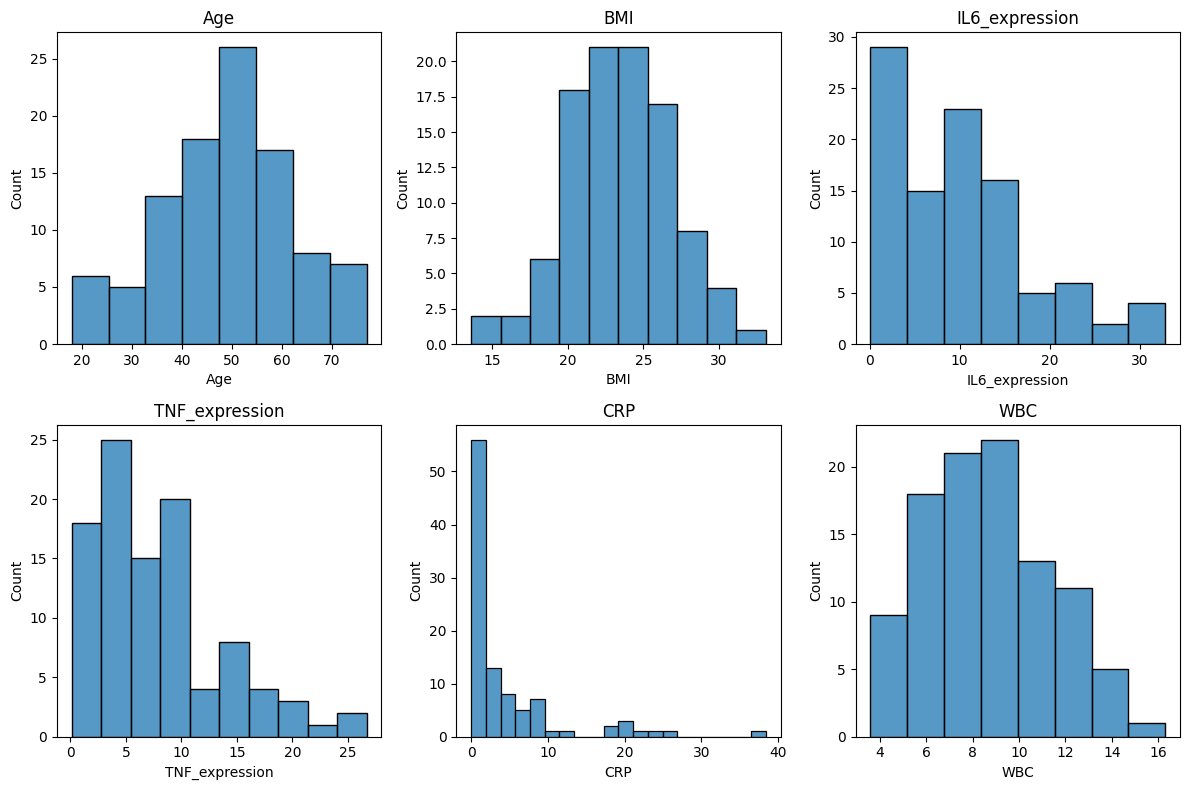

In [10]:
cols = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']

for c in cols:
    s, p = stats.shapiro(df[c])
    print(c, "p-value:", p)

plt.figure(figsize=(12, 8))
for i in range(len(cols)):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[cols[i]])
    plt.title(cols[i])

plt.tight_layout()
plt.show()

### 2. Диаграммы рассеяния

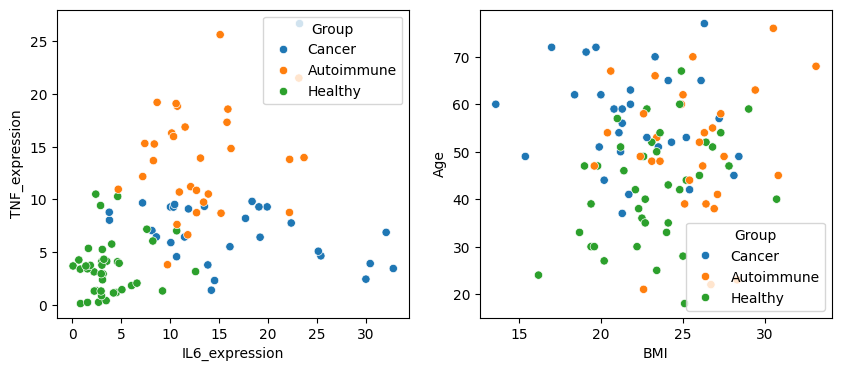

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='IL6_expression', y='TNF_expression', hue='Group')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='BMI', y='Age', hue='Group')

plt.show()

### 3. Матрица корреляций

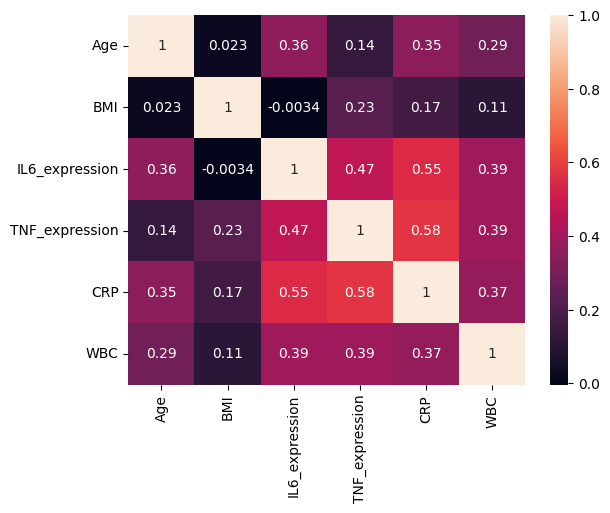

In [12]:
cols = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
corr_map = df[cols].corr(method='spearman')
sns.heatmap(corr_map, annot=True)
plt.show()

### 4. Корреляция IL6 и TNFα

In [13]:
r, p = stats.spearmanr(df['IL6_expression'], df['TNF_expression'])
print("Общая:", r, p)

for g in df['Group'].unique():
    data = df[df['Group'] == g]
    r, p = stats.spearmanr(data['IL6_expression'], data['TNF_expression'])
    print(g, ":", r, p)

Общая: 0.4699772275368377 8.083782720097087e-07
Cancer : -0.3059294712445078 0.1001482003259218
Autoimmune : 0.03670745272525028 0.8472906542071432
Healthy : 0.13725490256482328 0.39835815868454616


### 5. Сравнение IL6 (Healthy vs Cancer)

In [14]:
h = df[df['Group'] == 'Healthy']['IL6_expression']
c = df[df['Group'] == 'Cancer']['IL6_expression']
res = stats.mannwhitneyu(h, c)
print(res)

MannwhitneyuResult(statistic=np.float64(52.0), pvalue=np.float64(8.159540554362872e-11))


### 6. Сравнение возраста между 3 группами

In [15]:
g1 = df[df['Group'] == 'Healthy']['Age']
g2 = df[df['Group'] == 'Autoimmune']['Age']
g3 = df[df['Group'] == 'Cancer']['Age']
res = stats.f_oneway(g1, g2, g3)
print(res)

F_onewayResult(statistic=np.float64(12.379555685073347), pvalue=np.float64(1.627825414019538e-05))


### 7. CRP: Autoimmune vs Healthy

In [16]:
a = df[df['Group'] == 'Autoimmune']['CRP']
h = df[df['Group'] == 'Healthy']['CRP']
res = stats.mannwhitneyu(a, h, alternative='greater')
print(res)

MannwhitneyuResult(statistic=np.float64(1069.0), pvalue=np.float64(1.3115611464127392e-08))


### 8. Связь Группа и Аутоантитела

In [17]:
tab = pd.crosstab(df['Group'], df['Autoantibodies'])
res = stats.chi2_contingency(tab)
print("p-value:", res[1])

p-value: 4.6112827005185607e-07


### 9. Связь Пол и Аутоантитела (Autoimmune)

In [18]:
sub = df[df['Group'] == 'Autoimmune']
tab = pd.crosstab(sub['Gender'], sub['Autoantibodies'])
res = stats.fisher_exact(tab)
print("p-value:", res[1])

p-value: 0.1433854013164358


### 10. Сравнение Autoimmune vs Cancer по всем переменным

In [19]:
cols = ['Age', 'BMI', 'IL6_expression', 'TNF_expression', 'CRP', 'WBC']
a = df[df['Group'] == 'Autoimmune']
c = df[df['Group'] == 'Cancer']

for col in cols:
    res = stats.mannwhitneyu(a[col], c[col])
    print(col, "p-value:", res[1])

Age p-value: 0.08218682560959992
BMI p-value: 0.0003458649513878723
IL6_expression p-value: 0.13345408758779304
TNF_expression p-value: 6.523811813545671e-07
CRP p-value: 0.1535471902640417
WBC p-value: 0.9116820881479285
